<a href="https://colab.research.google.com/github/KasumiMercury/yolo_person_finetuning/blob/main/yolo_person_finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!nvidia-smi

from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_ROOT = "/content/drive/MyDrive/yolo26_person_ft"
RUNS_DIR   = f"{DRIVE_ROOT}/runs"          # 学習ログ/重み
WEIGHTS_DIR= f"{DRIVE_ROOT}/weights"       # 事前学習重みのキャッシュ
for p in [DRIVE_ROOT, RUNS_DIR, WEIGHTS_DIR]:
    os.makedirs(p, exist_ok=True)

print("DRIVE_ROOT =", DRIVE_ROOT)

Fri Apr 10 03:55:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
DATA_DIR = "/content/coco_person_yolo"   # ローカルSSDに展開

In [2]:
import shutil
shutil.rmtree(DATA_DIR)

In [5]:
import os, zipfile, shutil

ZIP_SRC  = f"{DRIVE_ROOT}/datasets/coco_person_yolo.zip"

if not os.path.isdir(DATA_DIR) or not os.listdir(DATA_DIR):
    os.makedirs(DATA_DIR, exist_ok=True)
    with zipfile.ZipFile(ZIP_SRC) as z:
        z.extractall(DATA_DIR)

import yaml
YAML_PATH = f"{DATA_DIR}/dataset.yaml"
with open(YAML_PATH, "w") as f:
    yaml.safe_dump({
        "path":  DATA_DIR,
        "train": "images/train",
        "val":   "images/val",
        "names": {0: "person"},
    }, f, sort_keys=False)
print(YAML_PATH)
print(open(YAML_PATH).read())

/content/coco_person_yolo/dataset.yaml
path: /content/coco_person_yolo
train: images/train
val: images/val
names:
  0: person



In [6]:
!pip -q install -U ultralytics pycocotools onnx onnxruntime-gpu

import ultralytics
ultralytics.checks()

Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 44.6/112.6 GB disk)


In [7]:
import os, shutil
from ultralytics import YOLO

BASE_MODEL = "yolo26n.pt"   # or "yolo26s.pt"

cached = os.path.join(WEIGHTS_DIR, BASE_MODEL)
if not os.path.exists(cached):
    # 初回のみダウンロード→Driveへコピー
    m = YOLO(BASE_MODEL)    # DL
    src = m.ckpt_path if hasattr(m, "ckpt_path") else BASE_MODEL
    if os.path.exists(src):
        shutil.copy(src, cached)
print("pretrained:", cached)

pretrained: /content/drive/MyDrive/yolo26_person_ft/weights/yolo26n.pt


In [8]:
# train
import os
from ultralytics import YOLO

RUN_NAME   = "yolo26n_person_ft"
PROJECT    = RUNS_DIR
LAST_CKPT  = f"{PROJECT}/{RUN_NAME}/weights/last.pt"

common_args = dict(
    data=YAML_PATH,
    epochs=100,
    imgsz=640,
    batch=32,            # Colab T4なら16〜32、A100なら64〜
    project=PROJECT,
    name=RUN_NAME,
    exist_ok=True,       # 再実行で同じディレクトリに上書き継続
    patience=20,         # early stopping
    cache="disk",        # Driveはread遅いが再DL回避のため
    workers=2,
    device=0,
    # --- person特化/軽量化向けの調整 ---
    single_cls=True,     # 単一クラス学習(nc=1)
    cos_lr=True,         # コサインLR
    close_mosaic=10,     # 終盤はmosaic無効化で収束安定
    # augmentation: personは形状変化が大きいので軽めに調整
    degrees=0.0,
    shear=0.0,
    perspective=0.0,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.1,
)

if os.path.exists(LAST_CKPT):
    print(f"[RESUME] from {LAST_CKPT}")
    model = YOLO(LAST_CKPT)
    results = model.train(resume=True)
else:
    print(f"[NEW] from {cached}")
    model = YOLO(cached)
    results = model.train(**common_args)

[NEW] from /content/drive/MyDrive/yolo26_person_ft/weights/yolo26n.pt
Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/coco_person_yolo/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=/content/drive/MyDrive/yolo26_person_ft/weights/yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.

['weights', 'args.yaml', 'labels.jpg', 'train_batch0.jpg', 'train_batch1.jpg', 'train_batch2.jpg', 'results.csv', 'train_batch5670.jpg', 'train_batch5671.jpg', 'train_batch5672.jpg', 'val_batch0_labels.jpg', 'val_batch0_pred.jpg', 'val_batch1_labels.jpg', 'val_batch1_pred.jpg', 'BoxPR_curve.png', 'val_batch2_labels.jpg', 'val_batch2_pred.jpg', 'BoxF1_curve.png', 'BoxP_curve.png', 'BoxR_curve.png', 'confusion_matrix_normalized.png', 'confusion_matrix.png', 'results.png']

=== results.png ===


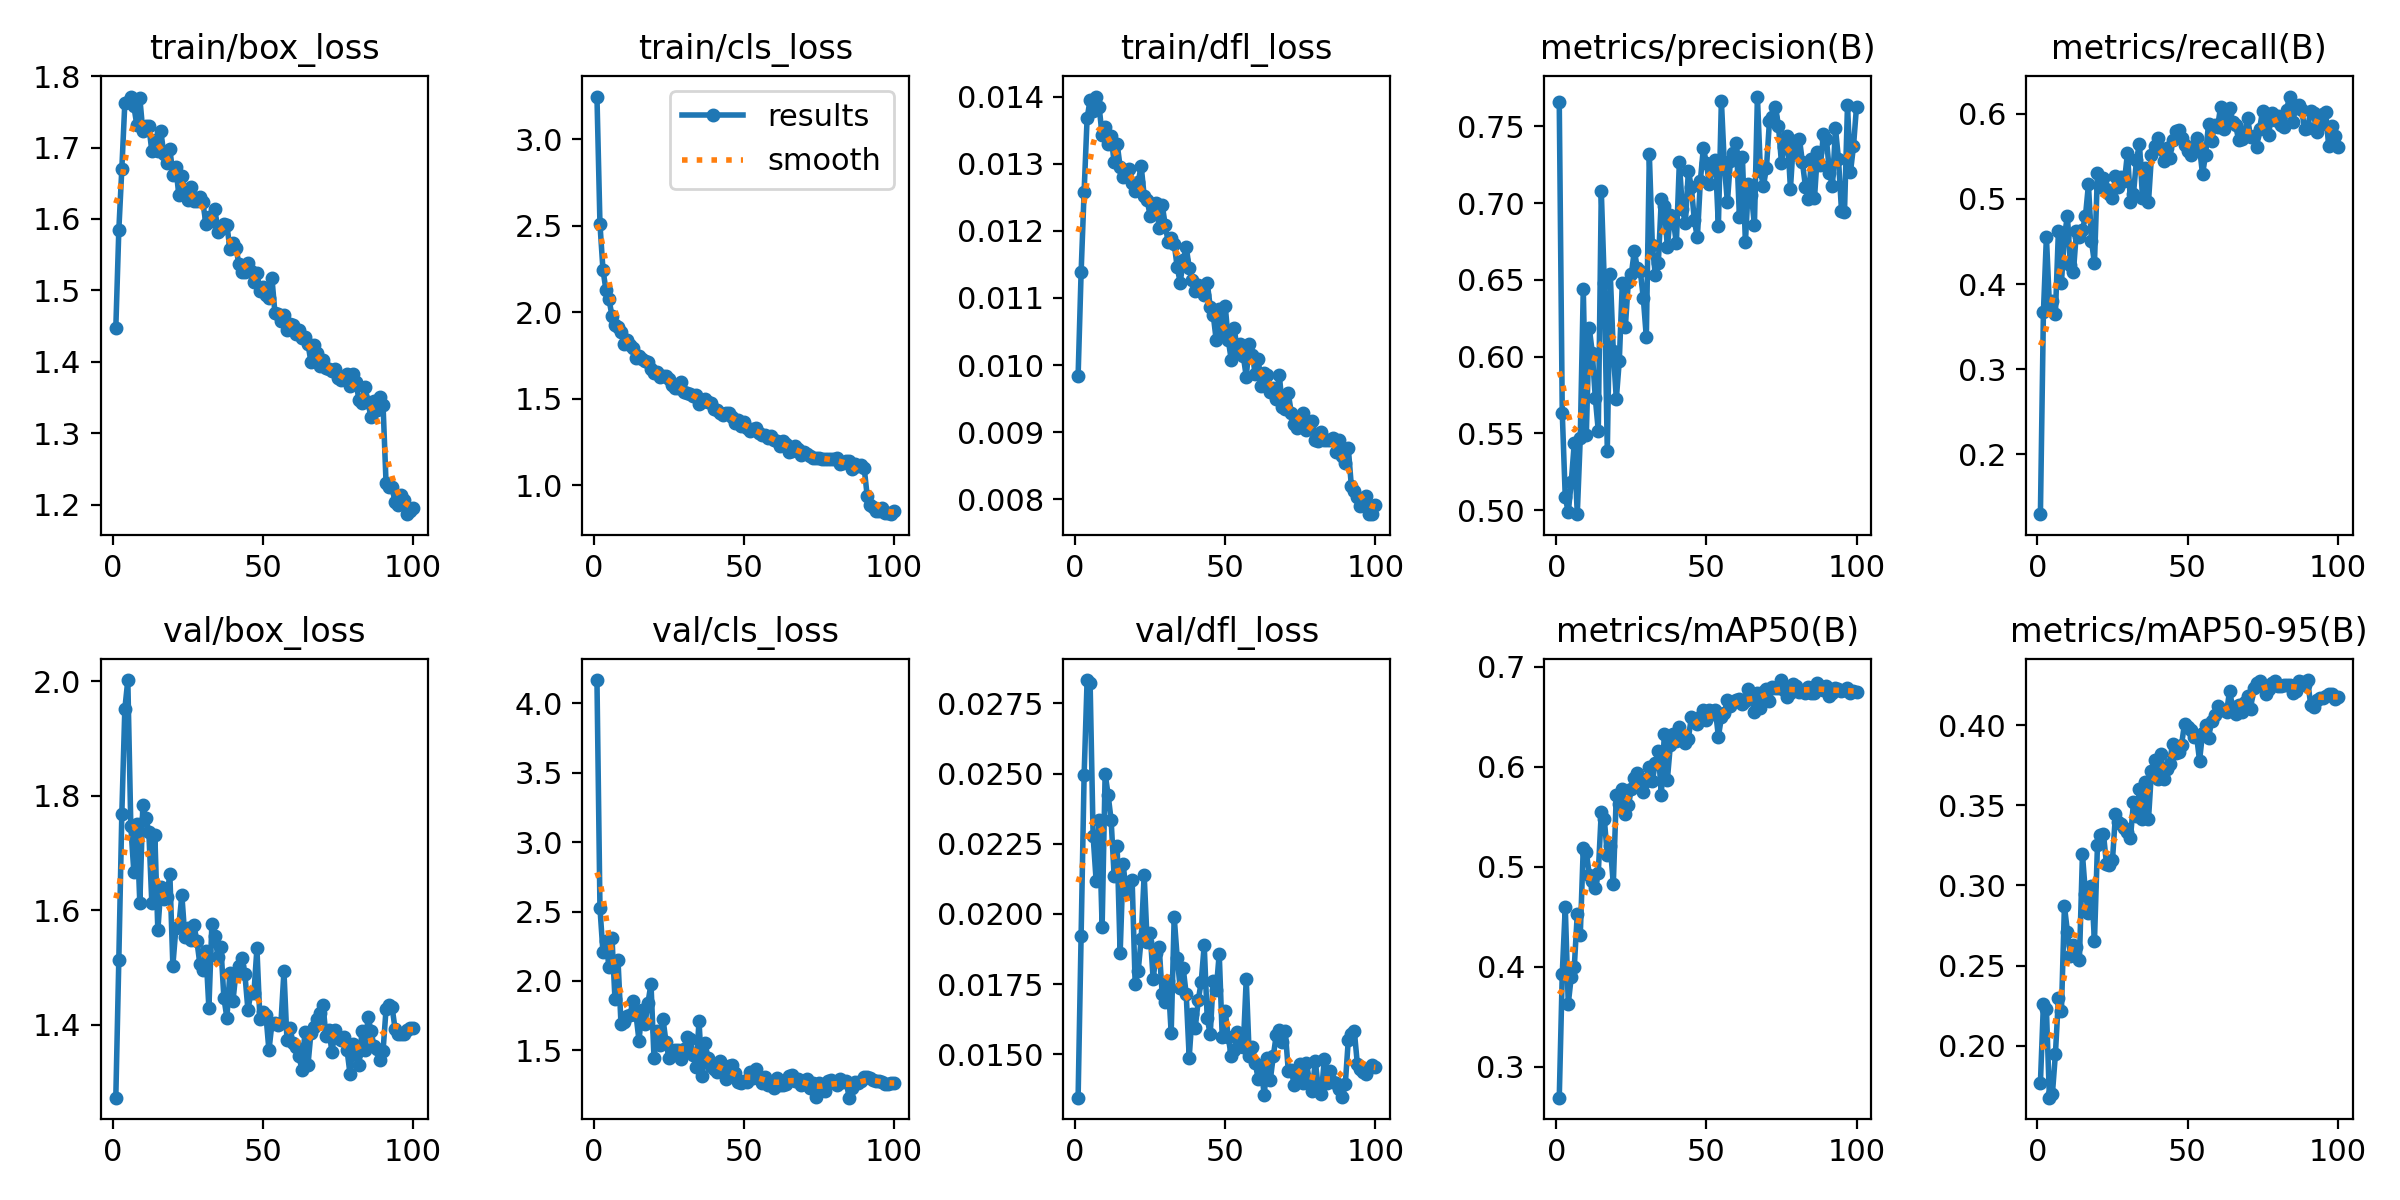


=== confusion_matrix.png ===


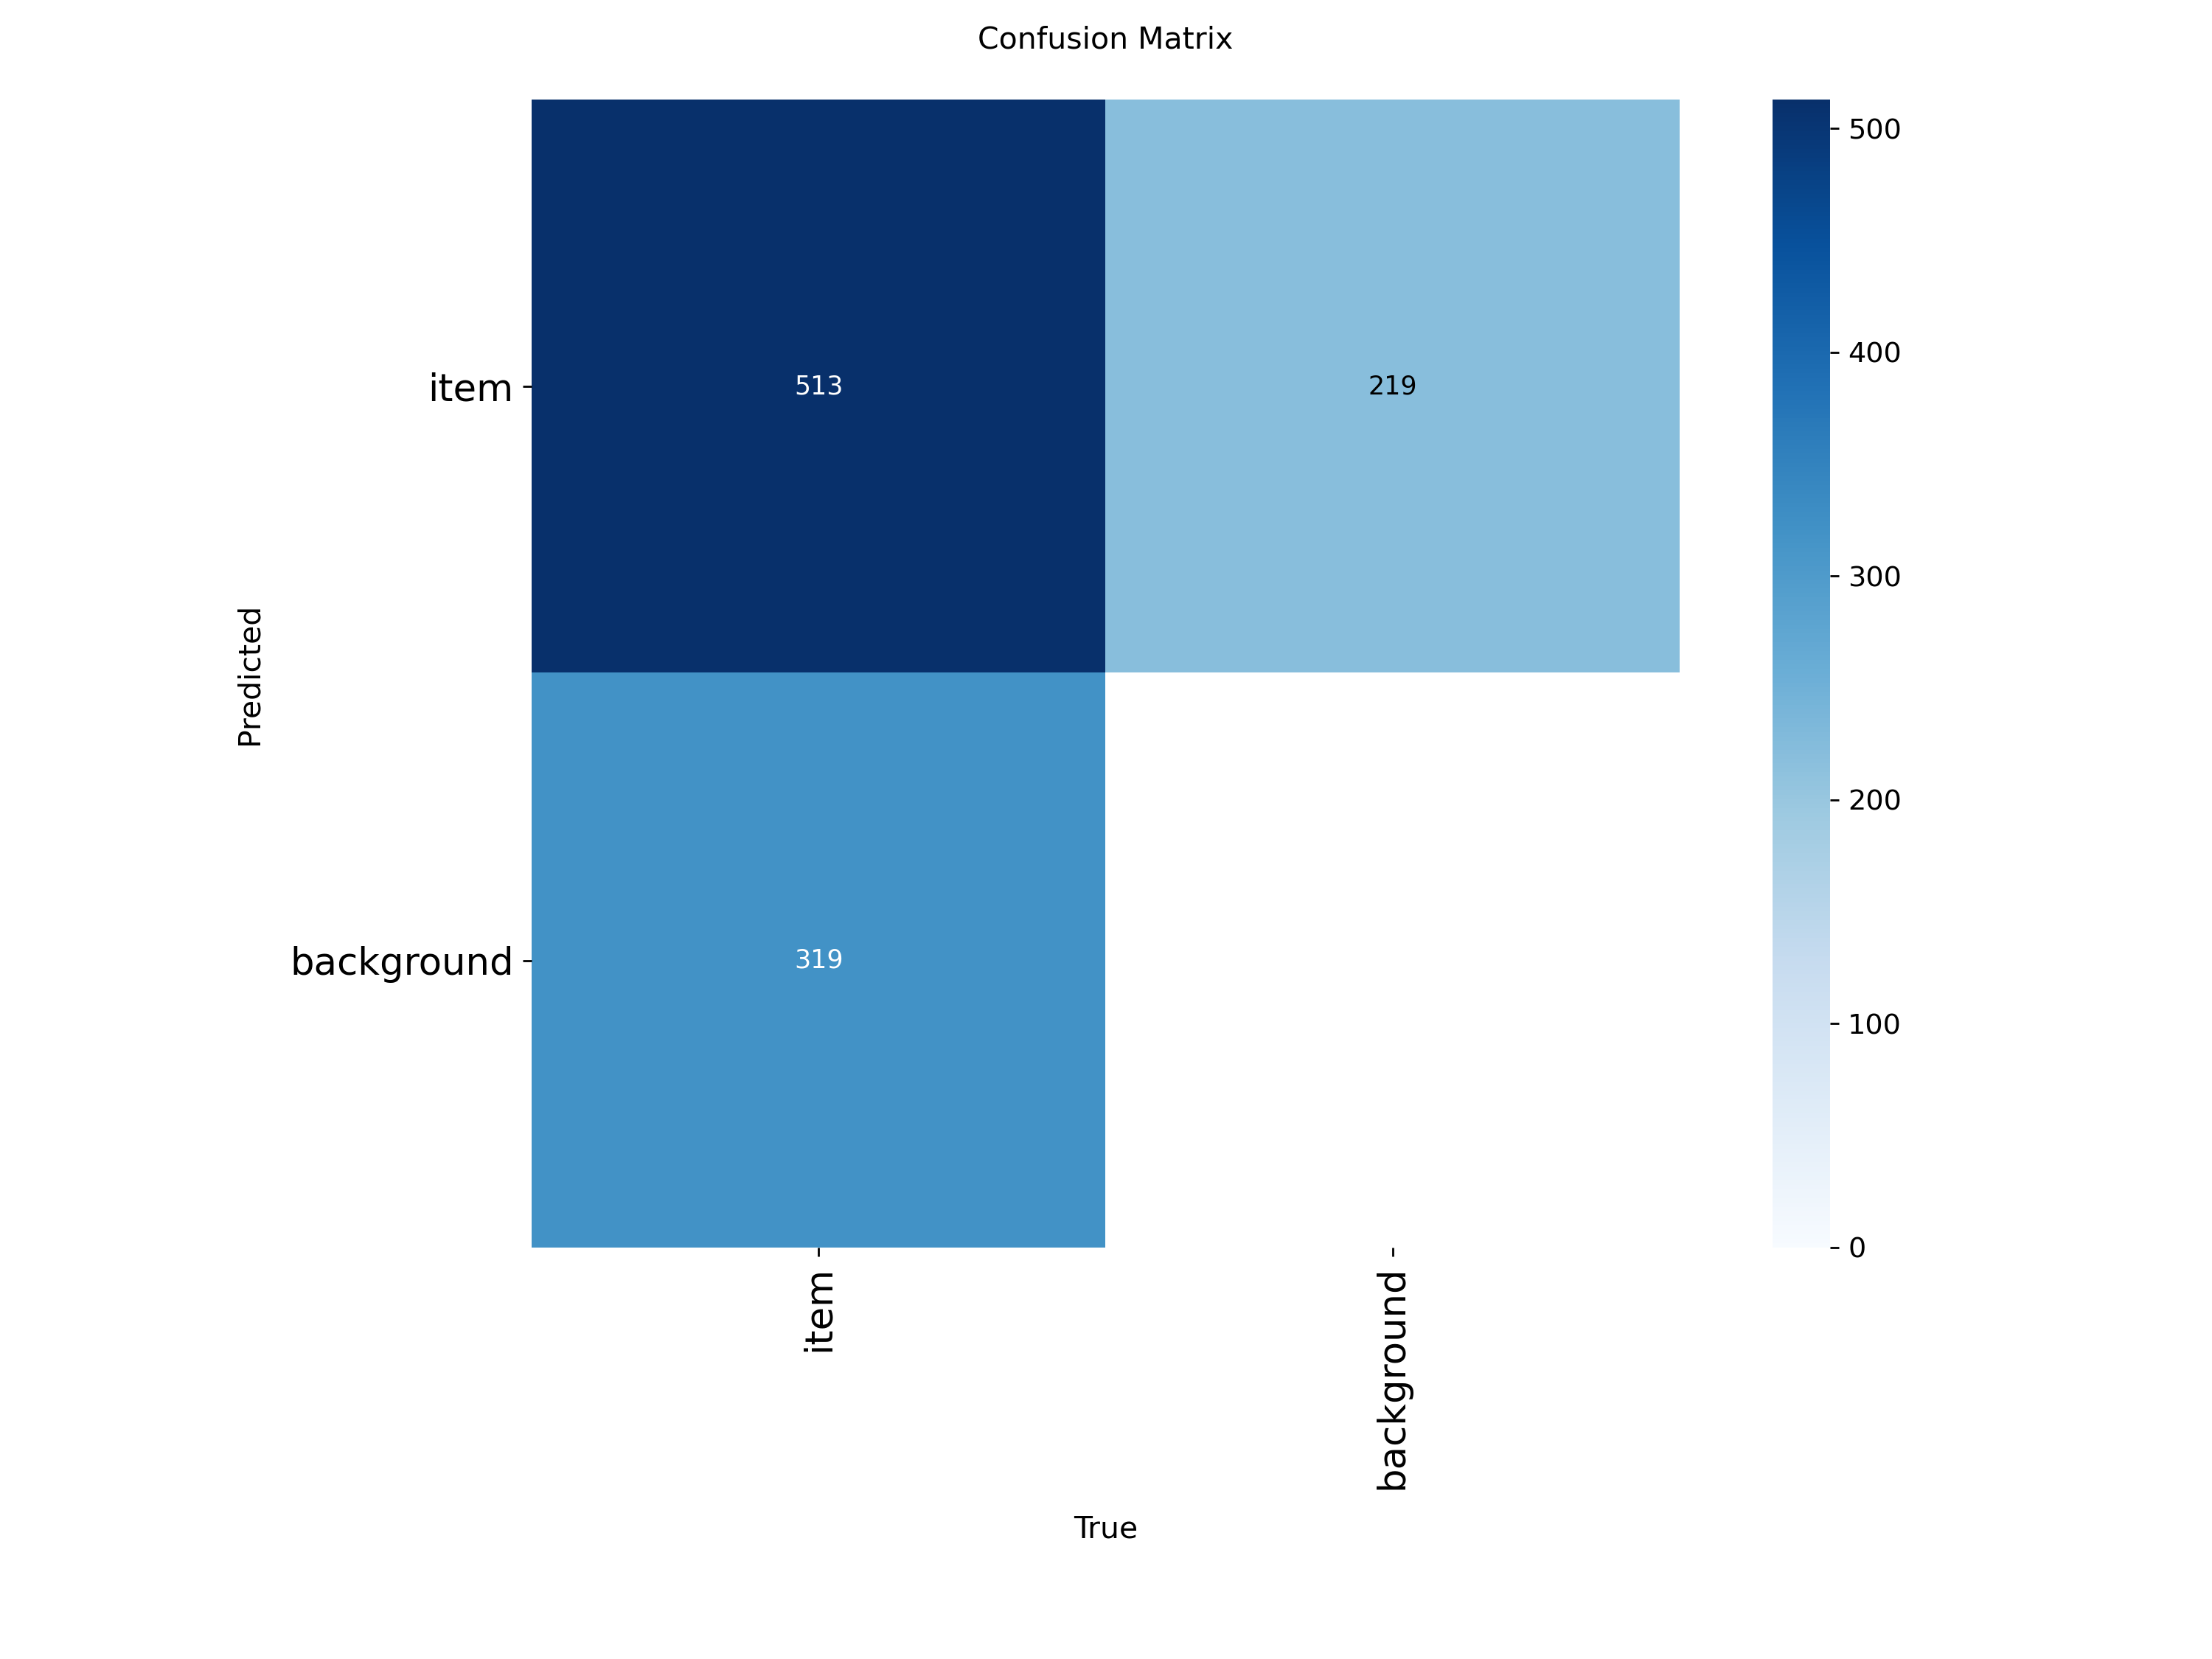


=== confusion_matrix_normalized.png ===


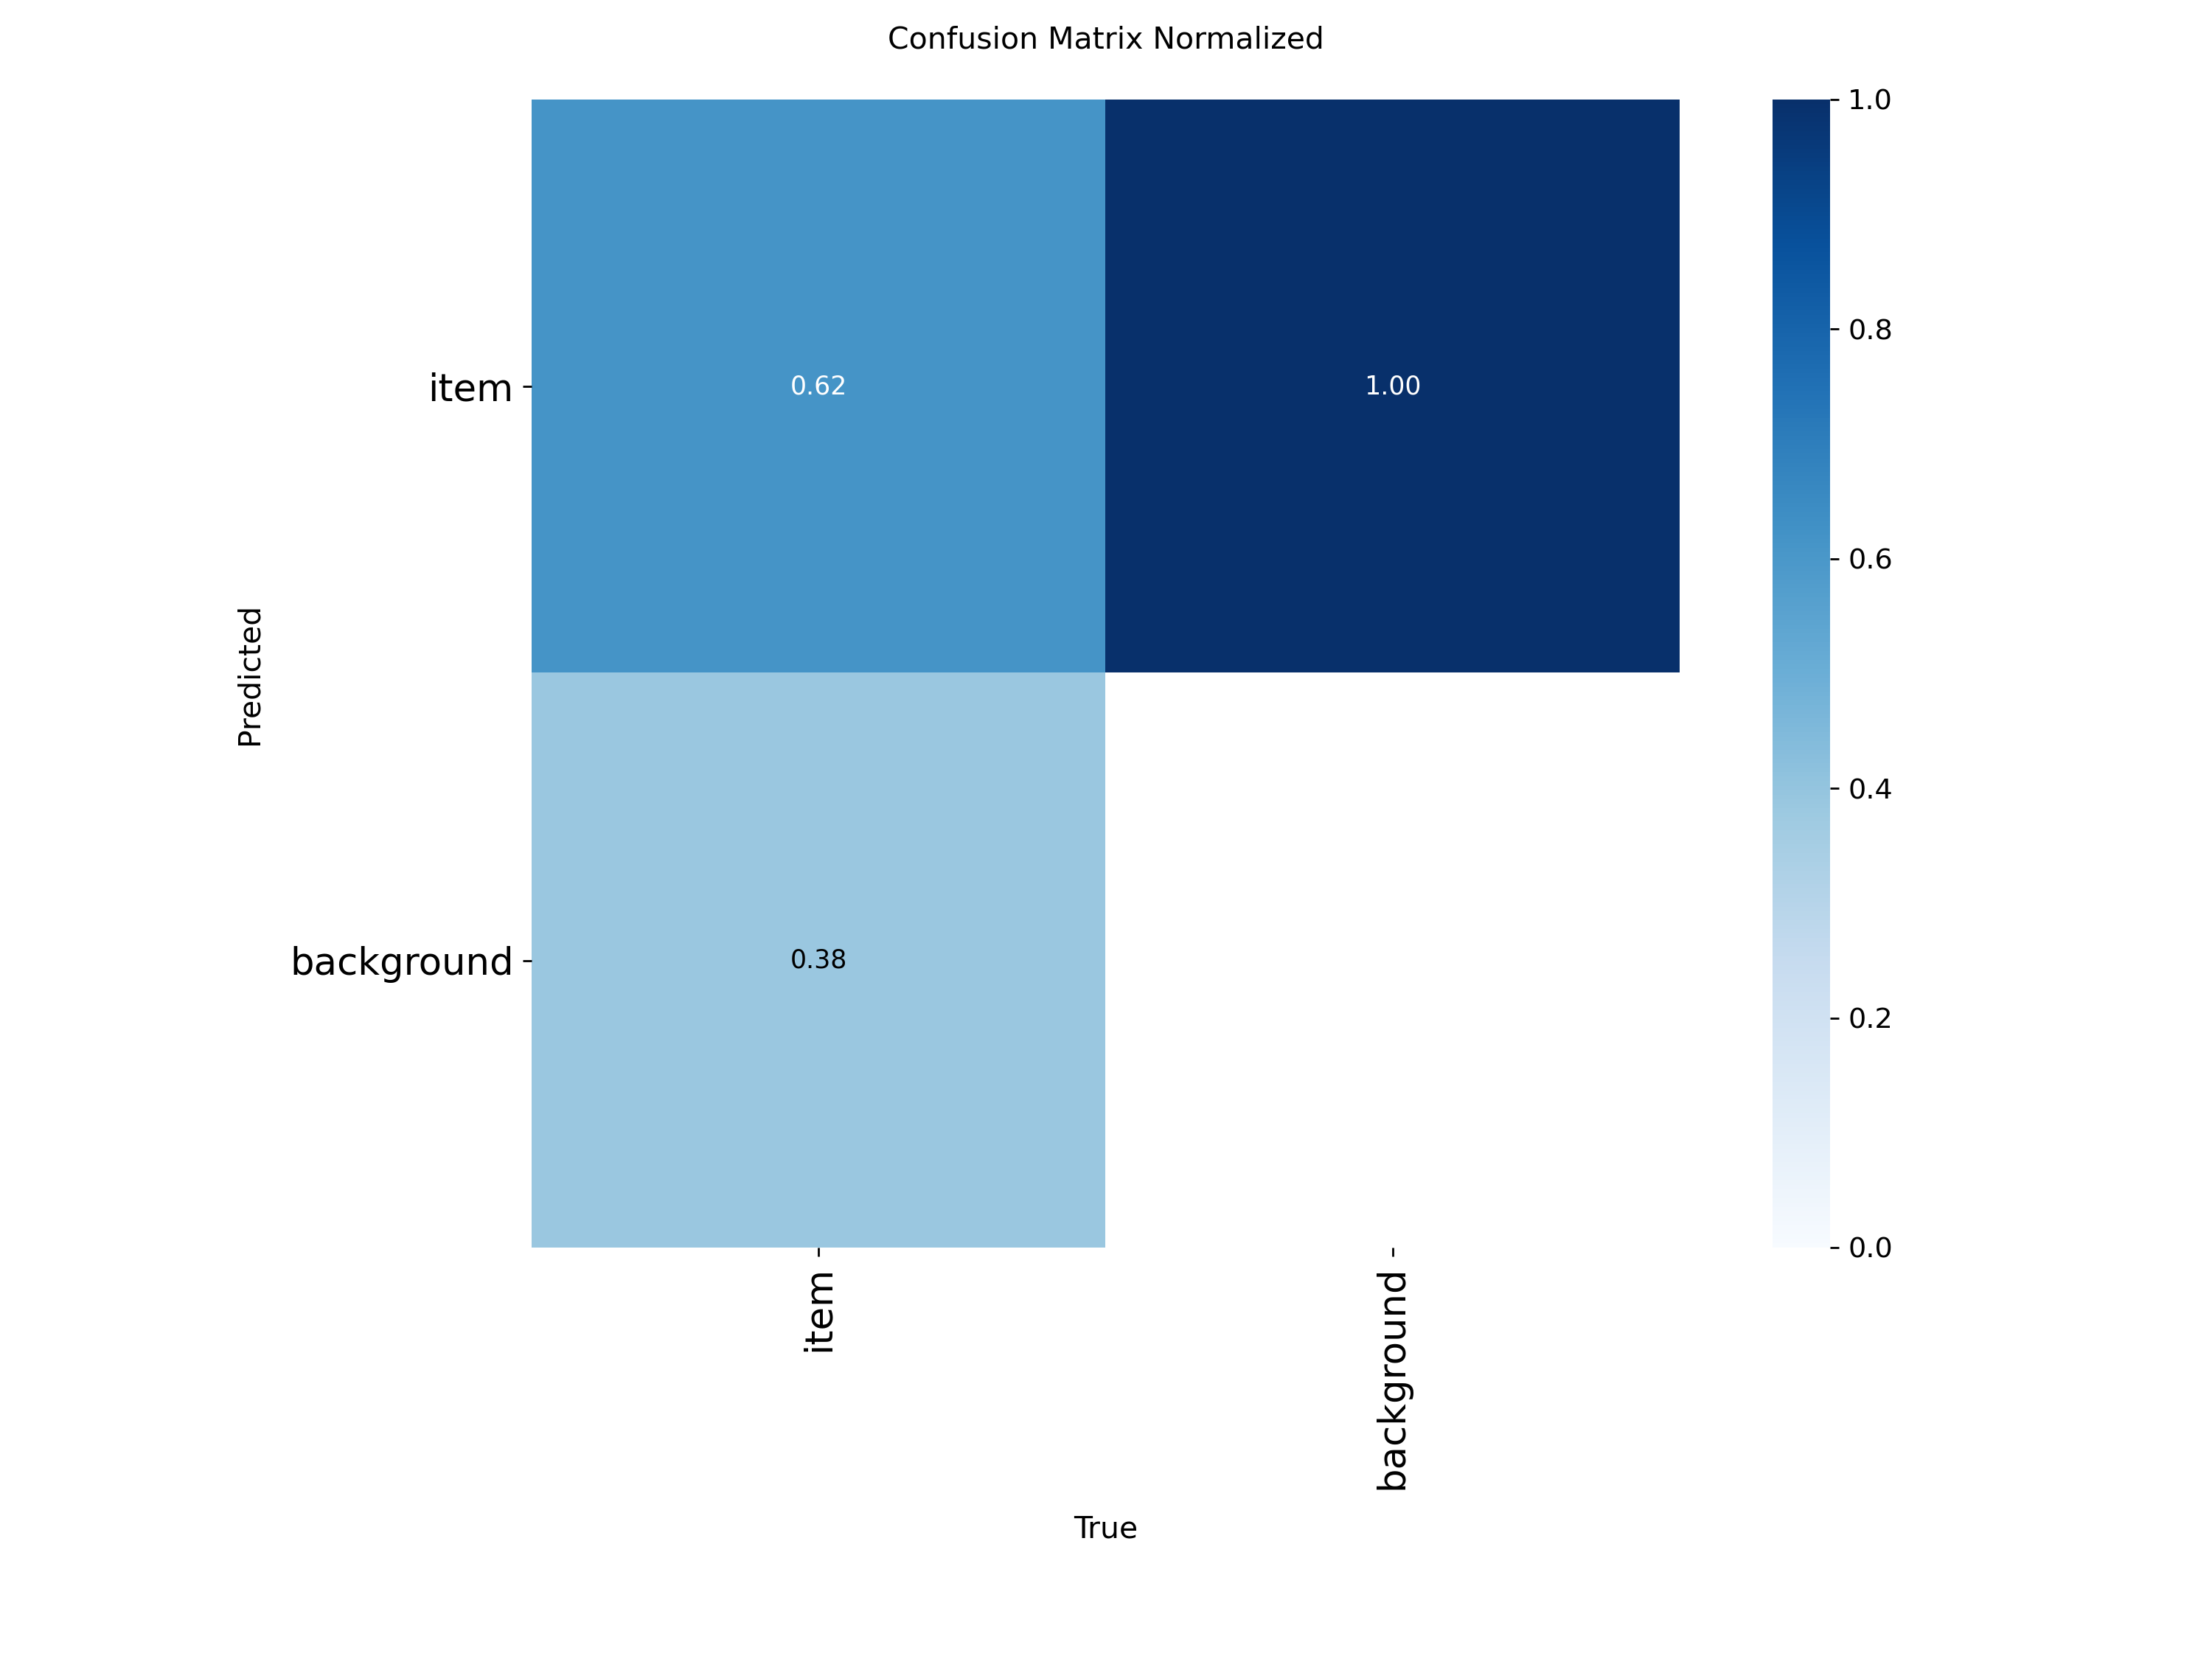


=== labels.jpg ===


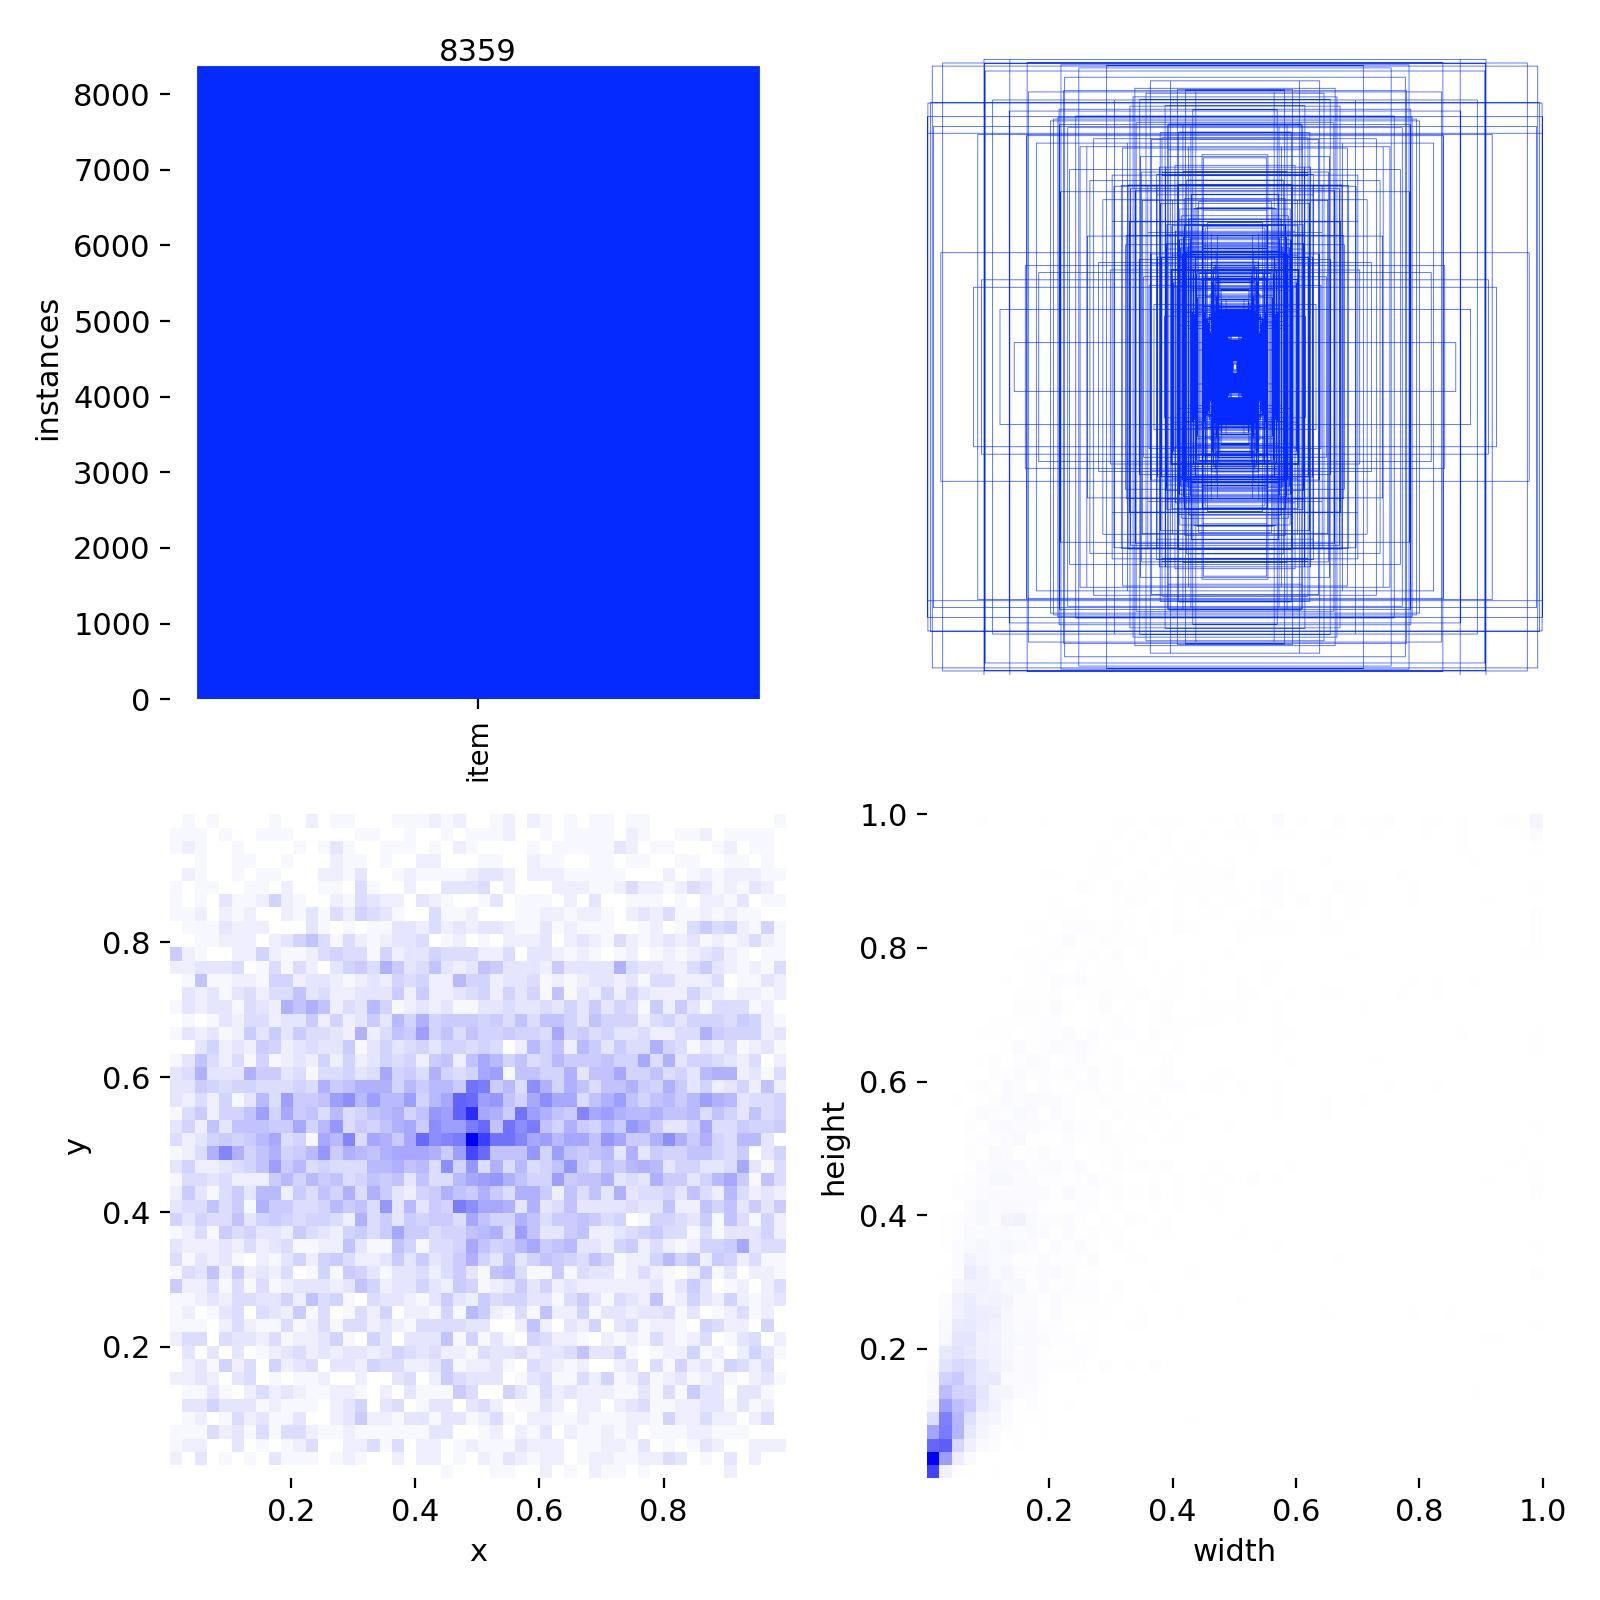

In [11]:
import os
from IPython.display import Image, display

RUN_DIR = f"{RUNS_DIR}/yolo26n_person_ft"
print(os.listdir(RUN_DIR))

for name in ["results.png", "confusion_matrix.png", "confusion_matrix_normalized.png",
             "PR_curve.png", "F1_curve.png", "P_curve.png", "R_curve.png", "labels.jpg"]:
    p = os.path.join(RUN_DIR, name)
    if os.path.exists(p):
        print(f"\n=== {name} ===")
        display(Image(p))

In [9]:
# validate
from ultralytics import YOLO

BEST = f"{PROJECT}/{RUN_NAME}/weights/best.pt"

# ファインチューニング後
ft = YOLO(BEST)
metrics_ft = ft.val(data=YAML_PATH, imgsz=640, split="val")
print("FT  mAP50-95:", metrics_ft.box.map, " mAP50:", metrics_ft.box.map50)

# 元の事前学習モデル(80クラス)をperson-onlyのvalで比較
# classes=[0] でpersonだけ評価
base = YOLO(cached)
metrics_base = base.val(data=YAML_PATH, imgsz=640, split="val", classes=[0])
print("Base mAP50-95:", metrics_base.box.map, " mAP50:", metrics_base.box.map50)

Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 482.2±1006.2 MB/s, size: 166.0 KB)
val: Scanning /content/coco_person_yolo/labels/val.cache... 200 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 200/200 76.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 5.0it/s 2.6s
                   all        200        832      0.733      0.588      0.684       0.43
Speed: 1.8ms preprocess, 4.6ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /content/runs/detect/val
FT  mAP50-95: 0.42964353176499703  mAP50: 0.683701127740345
Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,408,932 parameters, 0 gradients, 5.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, 

In [ ]:
# export

from ultralytics import YOLO
model = YOLO(BEST)

# ONNX (WebやONNX Runtimeで使用)
onnx_path = model.export(format="onnx", imgsz=640, opset=13, dynamic=True, simplify=True)
print("ONNX:", onnx_path)

# TFLite INT8 (エッジデバイス向け・さらなる軽量化)
# tflite_path = model.export(format="tflite", int8=True, data=YAML_PATH, imgsz=640)
# print("TFLite:", tflite_path)

In [ ]:
# test

from ultralytics import YOLO
model = YOLO(BEST)
res = model.predict(
    source=f"{DATA_DIR}/images/val",
    imgsz=640, conf=0.25,
    save=True,
    project=PROJECT, name=f"{RUN_NAME}_pred", exist_ok=True,
)
print("saved to:", res[0].save_dir)